# Using Classifier Free Guidance (CFG) with Diffusion

CFG involves a process where during training a certain percentage of training samples have the conditional replaced with a "null conditional" to simulate no conditional information. Then in generation, a guidance scale is set where the noise used is $\epsilon = \epsilon_u + g (\epsilon_c - \epsilon_u)$. Here $\epsilon_u$ is the noise generated by using the null conditional, and $\epsilon_c$ is the noise generated by using the conditional $c$. A guidance scale of 1 corresponds to just using $c$ and larger values represent more heavily weighting the conditional

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from synthetic_generation.diffusion.models import DiffusionNet
from synthetic_generation.diffusion.process import DiffusionProcess
from synthetic_generation.diffusion.schedules import linear_beta_schedule

In [14]:
def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Parameters
    ----------
    n_samples : int
        number of samples
    centers : int 
        number of disk clusters
    radius : float
        radius of ring containing centers of the clusters
    std : float
        standard deviation for distance from center of disk for a point
    seed : int
        random seed to use
    Returns
    -------
    tuple
        array of sample points, array of cluster centers for each point, array of labels for each cluster
    """
    rng = np.random.default_rng(seed)
    # compute the centers of each cluster
    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    # choose a random center and a random point in the cluster
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        # add the center and label
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [15]:
X_gauss, labels, centers = make_gaussian_mixture()

In [16]:
# make the conditional
one_hot_labels = F.one_hot(torch.tensor(labels)).float()
c = torch.cat([torch.Tensor(centers), one_hot_labels], dim=1)

In [5]:
DenoiseNet = DiffusionNet(data_dim=2, conditional_dim=10, num_hidden_layers=4,  hidden_dims=(256,256))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenoiseNet.to(device)

In [17]:
# turn the data into a tensor and move to device
X_train = torch.Tensor(X_gauss).to(device)
c=c.to(device)

In [18]:
diffusion_process = DiffusionProcess(
    model = model,
    num_timesteps = model.time_embedding.num_timesteps,
    betas=linear_beta_schedule(num_timesteps=model.time_embedding.num_timesteps)
)

In [19]:
diffusion_process.train(
    X=X_train,
    c=c,
    p_null=0.10
)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

In [34]:
def make_samples(n_samples, process, guidance_scale=1.0, c=c, seed=42):
    # small wrapper to create samples with a given scale
    torch.manual_seed(seed)
    samples = process.generate_samples(num_samples=n_samples, c=c[:n_samples], guidance_scale=guidance_scale)
    return samples

In [ ]:
# generate some samples with different guidance scales.
scales = [1,2,3,4,5]
samples = {}
for scale in scales:
    samples[scale] = make_samples(n_samples = 20000, process=diffusion_process, guidance_scale=scale)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

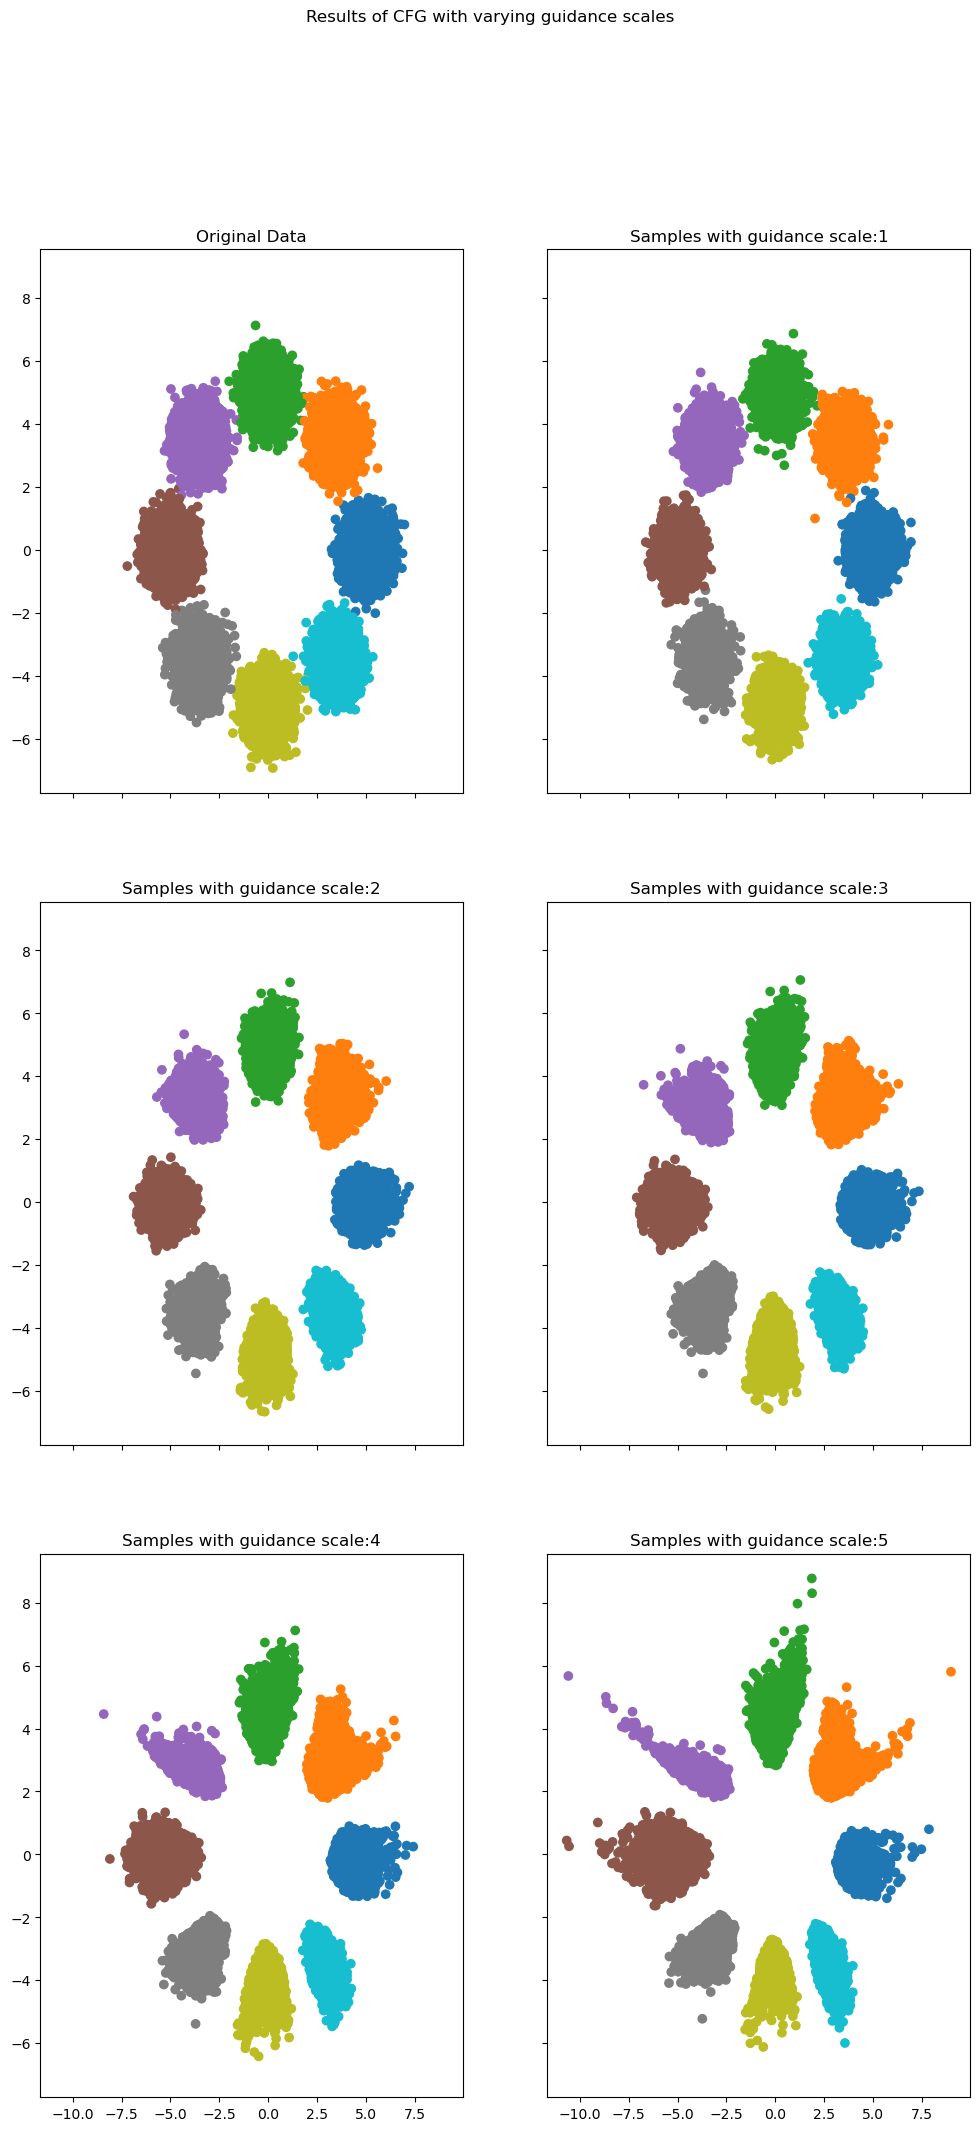

In [23]:
fig,axs = plt.subplots(3, 2, figsize=(12, 24), sharex=True, sharey=True)
axs_dict = {1:axs[0, 1], 2: axs[1, 0], 3: axs[1, 1], 4:axs[2, 0], 5:axs[2, 1]}
axs[0,0].scatter(X_gauss[:, 0],X_gauss[:, 1], c=labels, cmap="tab10")
axs[0,0].set_title("Original Data")
for scale in scales:
    ax = axs_dict[scale]
    sample = samples[scale]
    title=f"Samples with guidance scale:{scale}"
    ax.scatter(sample[:, 0], sample[:, 1], c=labels[:len(sample)], cmap="tab10")
    ax.set_title(title)
fig.suptitle("Results of CFG with varying guidance scales")
plt.show()

We can make a few observations. At a guidance scale of 1, which is essentially conditional diffusion, except that the model was trained with some samples and no conditional, the output is fairly close to the true data. As the guidance scale increases, we see two things. First, we observe that the clusters tighten and appear to be closer to the center of the cluster. This is expected from the guidance as increasing the scale increases the effect of the conditional. The other effect is that the clusters themselves start spreading outward radially. This is not related specifically to using cfg, but rather an artifact of our conditional. Our conditional consists of 2 parts, a one hot encoding of the lables, and the cluster centers. When we use our null conditional (in this case setting all the conditionals to 0), the zeros in the columns related to column center are no longer "null" but relate to the geometry of the data. Roughly speaking as we start increasing `guidance_scale` and we multiply $\epsilon_c$ by larger values, the model which is using those center values as geometric information actually starts moving it further in the direction of the center points. To see that this is really coming from the center values in the conditional, we repeat this process, but replace the combined conditional of cluster and center to just the one-hot encoded center.

In [24]:
# get a new conditional just using the one hot labels
c_l = one_hot_labels

In [25]:
# make a new network. Since there are only the one-hot encoded labels, conditional_dim is now 8
DenoiseNet_l = DiffusionNet(data_dim=2, conditional_dim=8, num_hidden_layers=4,  hidden_dims=(256,256))
model_l = DenoiseNet_l.to(device)

In [26]:
# X_train is unchanged, but we move c_l to the device
c_l = c_l.to(device)

In [28]:
# make a new process with this model
diffusion_process_l = DiffusionProcess(
    model = model_l,
    num_timesteps = model_l.time_embedding.num_timesteps,
    betas=linear_beta_schedule(num_timesteps=model_l.time_embedding.num_timesteps)
)

In [31]:
# train as before
diffusion_process_l.train(
    X=X_train,
    c=c_l,
    p_null=0.10
)

Diffusion training:   0%|          | 0/100 [00:00<?, ?it/s]

In [35]:
# as before make samples with varying guidance scale
samples_l = {}
for scale in scales:
    samples_l[scale] = make_samples(n_samples = 20000, process=diffusion_process_l,c=c_l, guidance_scale=scale)

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

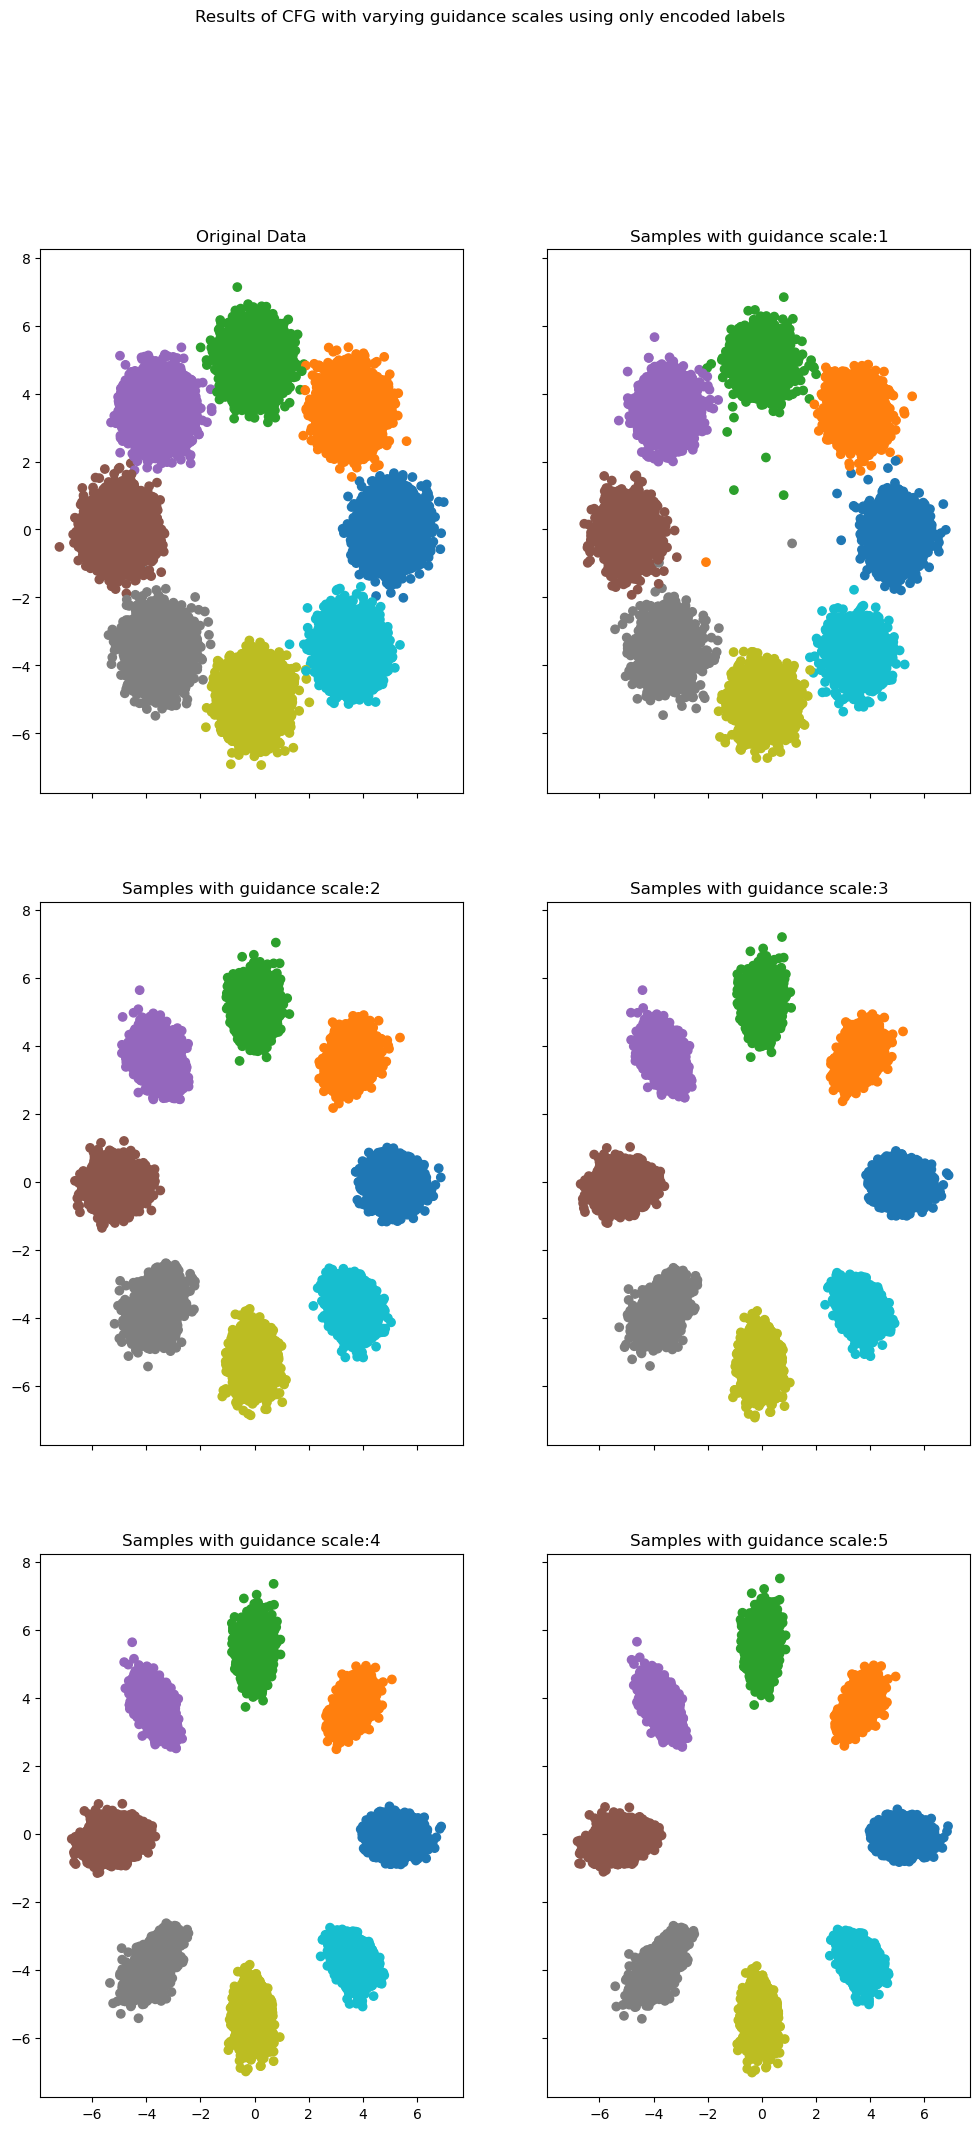

In [36]:
fig,axs = plt.subplots(3, 2, figsize=(12, 24), sharex=True, sharey=True)
axs_dict = {1:axs[0, 1], 2: axs[1, 0], 3: axs[1, 1], 4:axs[2, 0], 5:axs[2, 1]}
axs[0,0].scatter(X_gauss[:, 0],X_gauss[:, 1], c=labels, cmap="tab10")
axs[0,0].set_title("Original Data")
for scale in scales:
    ax = axs_dict[scale]
    sample = samples_l[scale]
    title=f"Samples with guidance scale:{scale}"
    ax.scatter(sample[:, 0], sample[:, 1], c=labels[:len(sample)], cmap="tab10")
    ax.set_title(title)
fig.suptitle("Results of CFG with varying guidance scales using only encoded labels")
plt.show()